# Tarea 1
__Curso:__ Tópicos avanzados en Inteligencia Artificial 1

__Programa:__ MIA 2-2025

__Profesor:__ Anthony D. Cho

__Ayudante corrector:__ Luis Oliveros

## Instrucciones
* La actividad debe ser realizada por los grupos capstones
* Por favor responder en este mismo notebook (una entrega por grupo)
* Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo actividad1_Sakuragi_Mitsui_Rukagua_Sendoh.ipynb
* Subir el archivo al link de entrega Actividad 1 en webcursos que será habilitado

__Fecha de entrega:__ Fecha límite de entrega 23 de agosto de 2026.

__Integrantes:__ (RUT, Nombre y Apellido)

* 13.257.556-8, Ricardo Lopez
* 16.789.149-7, Camilo Muñoz

## Librerias

In [1]:
import os
import matplotlib.pyplot as plt
from numpy import linspace, mean, argmin
from pandas import read_csv, DataFrame

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## Keras - tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

## Agregar las otras librerias que necesiten


In [8]:
import os
import random
import numpy as np
import tensorflow as tf

# Set Python hash seed
os.environ["PYTHONHASHSEED"] = "84"

# Set TF deterministic ops
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# Set random seeds for reproducibility
random.seed(84)
np.random.seed(84)
tf.keras.utils.set_random_seed(84)

# Enable deterministic operations for GPU (if available)
tf.config.experimental.enable_op_determinism()

print("Reproducibility settings applied.")

Reproducibility settings applied.


## Funciones personalizadas

In [2]:
def plot_history(history, width=12, height=6):
  """
  DESCRIPTION:
    History performance of the keras model

  INPUT:
    @param history: history of performance of fitted model
    @type history: tensorflow.python.keras.callbacks.History

  OUTPUT:
    A graphic
  """

  ## Metrics keys stored in tensorflow object
  keys = list(history.history.keys())

  ## Number of epoch used for fit the model
  epoch = range(1, len(history.epoch) +1)

  ## Check if validation set was used.
  withValidation = False
  for key in keys:
    if 'val' in key:
      withValidation = True

  ## Number of metrics
  nMetrics = len(keys)
  if withValidation:
    nMetrics = nMetrics//2

  ## Plot-space instance
  plt.figure(figsize=(width, height))

  for i in range(nMetrics):
    plt.subplot(nMetrics, 1, i+1)

    ## Plot (train) metric value
    labelMetric = keys[i]
    metric = history.history[keys[i]]
    plt.plot(epoch, metric, 'o-', label=labelMetric)

    if withValidation:
      ## Plot (validation) metric value
      labelMetricVal = keys[i+nMetrics]
      metricVal = history.history[keys[i+nMetrics]]
      plt.plot(epoch, metricVal, 'o-', label=labelMetricVal)

    plt.xlim(epoch[0], epoch[-1])
    plt.legend()
    plt.grid()

  plt.xlabel('Epoch')
  plt.show()

## Dataset

<center>
    <img src=https://www.xenonstack.com/hs-fs/hubfs/xenonstack-credit-card-fraud-detection.png?width=1920&height=1080&name=xenonstack-credit-card-fraud-detection.png width=800>
</center>

El conjunto de datos contiene transacciones realizadas con tarjetas de crédito en septiembre de 2013 en usuarios europeos.
Este conjunto de datos presenta transacciones que ocurrieron en dos días, donde tiene diagnosticado 492 casos fraudes de 284.807 transacciones. El conjunto de datos está muy desequilibrado, la clase positiva (fraudes) representa el 0,172% de todas las transacciones.

* La data y detalles está completamente disponible en [Kaggle: Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)

<p style="color:red"> <b>Instrucciones para usuarios que usan Windows: </b></p>

* Descargar la data pulsando [¡¡AQUI!!](https://github.com/adoc-box/Datasets/raw/main/creditcard.zip)
* Descomprime el archivo __creditcard.zip__. Luego, dejar el archivo __'creditcard.csv__ junto con el script.
* Ya con eso, debería poder ejecutar el script sin ningun problema.

In [3]:
dataset_name = 'creditcard.csv'

## Solo para Linux y MacOS
if os.name == 'posix':
    if not os.path.exists("creditcard.zip"):
        ## Download files

        !wget https://github.com/adoc-box/Datasets/raw/main/creditcard.zip

        ## un-compress joined zip file
        !unzip creditcard.zip

    else:
        if os.path.exists(dataset_name):
            !rm creditcard.csv
        !unzip creditcard.zip

else:
    print('Seguir las instrucciones para usuarios de Windows mencionado arriba.')

--2026-08-20 02:47:09--  https://github.com/adoc-box/Datasets/raw/main/creditcard.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adoc-box/Datasets/main/creditcard.zip [following]
--2026-08-20 02:47:09--  https://raw.githubusercontent.com/adoc-box/Datasets/main/creditcard.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66348190 (63M) [application/zip]
Saving to: ‘creditcard.zip’

creditcard.zip      100%[===================>]  63.27M   180MB/s    in 0.4s    

2026-08-20 02:47:12 (180 MB/s) - ‘creditcard.zip’ saved [66348190/66348190]

Archive:  creditcard.zip
  inflating: creditcard.csv 

In [9]:
dataset_name = 'creditcard.csv'

# Define possible paths for the dataset
possible_paths = [
    '/content/creditcard/creditcard.csv',
    '/content/creditcard.csv',
    'creditcard/creditcard.csv',
    'creditcard.csv'
]

# Try to find and load the dataset
data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path:
    print(f"Found dataset at: {data_path}")
    data = read_csv(data_path)
else:
    print("Error: Dataset 'creditcard.csv' not found in any of the expected locations.")
    print("Please ensure 'creditcard.csv' is available at one of these paths:")
    for path in possible_paths:
        print(f"- {path}")
    # If the file is not found, you might want to raise an error or handle it appropriately
    # For now, we'll proceed assuming it will be found in a later step if this code is modified.

print("No. of unique labels ", len(data['Class'].unique()))
print("Label values ",data.Class.unique())
# 0 is for normal credit card transaction
# 1 is for fraudulent credit card transaction

print('-------')
print("Break down of the Normal and Fraud Transactions")
print( data['Class'].value_counts(sort = True), end=2*'\n' )

data.head()

Found dataset at: /content/creditcard.csv
No. of unique labels  2
Label values  [0 1]
-------
Break down of the Normal and Fraud Transactions
Class
0    284315
1       492
Name: count, dtype: int64



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
## Load data
data = read_csv('creditcard.csv')

print("No. of unique labels ", len(data['Class'].unique()))
print("Label values ",data.Class.unique())
# 0 is for normal credit card transaction
# 1 is for fraudulent credit card transaction

print('-------')
print("Break down of the Normal and Fraud Transactions")
print( data['Class'].value_counts(sort = True), end=2*'\n' )

data.head()

No. of unique labels  2
Label values  [0 1]
-------
Break down of the Normal and Fraud Transactions
Class
0    284315
1       492
Name: count, dtype: int64



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


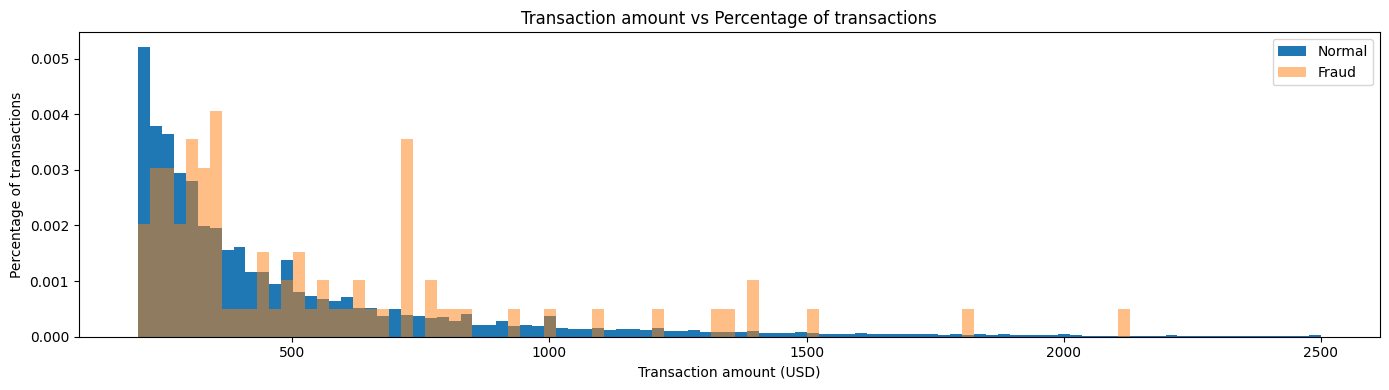

In [5]:
## Data splitting: the normal and fradulent transactions in separate dataframe
normal_data = data.query("Class == 0")
fraud_data = data.query("Class == 1")

## Visualize transaction amounts for normal and fraudulent transactions
bins = linspace(200, 2500, 100)
plt.figure(figsize=(14, 4))
plt.hist(normal_data.Amount, bins=bins, alpha=1, density=True, label='Normal')
plt.hist(fraud_data.Amount, bins=bins, alpha=0.5, density=True, label='Fraud')
plt.legend(loc='upper right')
plt.title("Transaction amount vs Percentage of transactions")
plt.xlabel("Transaction amount (USD)"); plt.ylabel("Percentage of transactions");
plt.tight_layout()
plt.show()

In [6]:
data.describe(include='all')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Data pre-processing

In [7]:
## predictors and labels assigments
X, Y = data.drop(columns=['Time', 'Class']), data['Class']

## Train, validate and test set
X_trainVal, X_test, y_trainVal, y_test = train_test_split(X, Y, stratify=Y,
                                                          test_size=0.2,
                                                          random_state=84)

X_train, X_val, y_train, y_val = train_test_split(X_trainVal, y_trainVal,
                                                  stratify=y_trainVal,
                                                  test_size=0.2,
                                                  random_state=84)

print('Train (Shape) - X: {}, y: {}'.format(X_train.shape, y_train.shape))
print('Val (Shape) - X: {}, y: {}'.format(X_val.shape, y_val.shape))
print('Test (Shape) - X: {}, y: {}\n'.format(X_test.shape, y_test.shape))


## Extract normal (no fraud) data for training and validate
X_train_normal = X_train[ y_train.values == 0 ]
X_val_normal = X_val[ y_val.values == 0 ]
X_trainVal_normal = X_trainVal[ y_trainVal.values == 0 ]

print('Train (Shape) Normal cases - X: {}'.format(X_train_normal.shape))
print('Val (Shape) Normal cases - X: {}'.format(X_val_normal.shape))
print('Train+Val (Shape) Normal cases - X: {}'.format(X_trainVal_normal.shape))



## Data normalization
scaler = MinMaxScaler().fit(X_train_normal)
X_train_normal = scaler.transform(X_train_normal)
X_val_normal = scaler.transform(X_val_normal)
X_trainVal_normal = scaler.transform(X_trainVal_normal)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Train (Shape) - X: (182276, 29), y: (182276,)
Val (Shape) - X: (45569, 29), y: (45569,)
Test (Shape) - X: (56962, 29), y: (56962,)

Train (Shape) Normal cases - X: (181961, 29)
Val (Shape) Normal cases - X: (45490, 29)
Train+Val (Shape) Normal cases - X: (227451, 29)


## Paso 1 (5 puntos):

Utilice el conjunto de entrenamiento y validación de la mejor forma tal de poder definir los hiperparámetros (número de capas ocultas, número de unidades en las capas, funciones de activación, número de épocas) de un modelo **Autoencoder Variacional (VAE)**  para abordar el problema de detección de fraudes siguiendo un enfoque similar al ejemplo de Vanilla Autoencoder visto en clases.

Deje las 3 mejores cofiguraciones probados reportando también las métricas MAE y MSE de los conjuntos de entrenamiento y validación. También indiquen con cuál de las 3 configuraciones eligirian como su mejor opción.

## Paso 1: Implementación y optimización del Autoencoder Variacional (VAE)

En esta sección, implementaremos un Autoencoder Variacional (VAE) utilizando TensorFlow y Keras. El VAE constará de un codificador (Encoder) que mapea los datos de entrada a un espacio latente, una capa de muestreo (Sampling Layer) que utiliza la reparametrización para generar muestras del espacio latente, y un decodificador (Decoder) que reconstruye los datos a partir de estas muestras. La pérdida total del VAE incluirá tanto la pérdida de reconstrucción como la divergencia KL para regularizar el espacio latente.

Se entrenarán al menos tres configuraciones diferentes del VAE, variando hiperparámetros como el número de capas ocultas, unidades, dimensión latente, función de activación, tamaño del batch y número de épocas. Utilizaremos EarlyStopping para detener el entrenamiento cuando la pérdida de validación no mejore y restaurar los pesos del mejor modelo. Los resultados de cada configuración serán tabulados para identificar la mejor opción.

In [1]:
from tensorflow.keras import Model
import keras.ops as ops # Use keras.ops for backend-agnostic operations
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers


# Custom Sampling Layer for VAE
class Sampling(layers.Layer):
    """
    Uses (z_mean, z_log_var) to sample z, the vector encoding a digit.
    """

    def call(self, inputs, training=None):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]

        # During training, sample with epsilon. During inference, return z_mean directly.
        if training:
            epsilon = ops.random.normal(shape=(batch, dim), seed=84) # Reproducible epsilon
            return z_mean + ops.exp(0.5 * z_log_var) * epsilon
        else:
            return z_mean # During inference, return z_mean directly


# Define the VAE model
def create_vae_model(input_dim, hidden_layers_encoder, hidden_layers_decoder, latent_dim, activation):
    # Encoder
    encoder_inputs = layers.Input(shape=(input_dim,))
    x = encoder_inputs
    for units in hidden_layers_encoder:
        x = layers.Dense(units, activation=activation)(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    # Decoder
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = latent_inputs
    for units in hidden_layers_decoder:
        x = layers.Dense(units, activation=activation)(x)
    decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(x) # Sigmoid for MinMaxScaler scaled data
    decoder = Model(latent_inputs, decoder_outputs, name="decoder")

    # VAE
    outputs = decoder(encoder(encoder_inputs)[2])
    vae = Model(encoder_inputs, outputs, name="vae_mlp")

    # VAE Loss
    # reconstruction_loss = MeanSquaredError(reduction=tf.keras.losses.Reduction.SUM)(encoder_inputs, outputs)
    # The above gives an error when scaling the loss by input_dim with Keras 3 and ops.
    # Let's calculate MSE directly and then multiply.
    reconstruction_loss_per_sample = ops.sum(ops.square(encoder_inputs - outputs), axis=1)
    reconstruction_loss = ops.mean(reconstruction_loss_per_sample)

    kl_loss = -0.5 * ops.sum(1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=-1)
    vae_loss = ops.mean(reconstruction_loss + kl_loss)
    vae.add_loss(vae_loss)
    vae.compile(optimizer=Adam(learning_rate=1e-3))

    return vae, encoder, decoder


# --- Hyperparameter configurations to test ---
configurations = [
    {
        'name': 'Config_1 (Small)',
        'hidden_layers_encoder': [16, 8],
        'hidden_layers_decoder': [8, 16],
        'latent_dim': 4,
        'activation': 'relu',
        'epochs': 50,
        'batch_size': 256,
        'learning_rate': 1e-3
    },
    {
        'name': 'Config_2 (Medium)',
        'hidden_layers_encoder': [32, 16],
        'hidden_layers_decoder': [16, 32],
        'latent_dim': 8,
        'activation': 'relu',
        'epochs': 50,
        'batch_size': 512,
        'learning_rate': 1e-3
    },
    {
        'name': 'Config_3 (Large)',
        'hidden_layers_encoder': [64, 32, 16],
        'hidden_layers_decoder': [16, 32, 64],
        'latent_dim': 16,
        'activation': 'tanh',
        'epochs': 50,
        'batch_size': 1024,
        'learning_rate': 5e-4
    }
]

# Store results
results = []

input_dim = X_train_normal.shape[1] # All 'V' features and 'Amount' (after scaling)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Loop through configurations and train VAEs
for config in configurations:
    print(f"\nTraining {config['name']}...")

    # Create VAE model
    vae, encoder, decoder = create_vae_model(
        input_dim=input_dim,
        hidden_layers_encoder=config['hidden_layers_encoder'],
        hidden_layers_decoder=config['hidden_layers_decoder'],
        latent_dim=config['latent_dim'],
        activation=config['activation']
    )
    # Update learning rate
    vae.optimizer.learning_rate.assign(config['learning_rate'])

    # Train the VAE
    history = vae.fit(X_train_normal, X_train_normal, # VAE is unsupervised, input = output
                      epochs=config['epochs'],
                      batch_size=config['batch_size'],
                      shuffle=True, # Shuffle=True is acceptable with fixed seeds
                      validation_data=(X_val_normal, X_val_normal),
                      callbacks=[early_stopping],
                      verbose=0,
                      # Pass training=True explicitly during fit for custom layers
                      # that behave differently during training vs. inference.
                      # The Sampling layer now uses this argument.
                      training=True
                      )

    # Predict reconstruction for train and validation sets
    # Pass training=False explicitly during predict to ensure z_mean is returned.
    X_train_pred = vae.predict(X_train_normal, verbose=0, training=False)
    X_val_pred = vae.predict(X_val_normal, verbose=0, training=False)

    # Calculate MAE and MSE
    train_mae = np.mean(np.abs(X_train_normal - X_train_pred))
    train_mse = np.mean(np.square(X_train_normal - X_train_pred))
    val_mae = np.mean(np.abs(X_val_normal - X_val_pred))
    val_mse = np.mean(np.square(X_val_normal - X_val_pred))

    results.append({
        'name': config['name'],
        'hidden_layers': config['hidden_layers_encoder'], # For simplicity, representing with encoder layers
        'latent_dim': config['latent_dim'],
        'activation': config['activation'],
        'epochs': len(history.history['loss']), # Actual epochs run due to EarlyStopping
        'batch_size': config['batch_size'],
        'learning_rate': config['learning_rate'],
        'train_mae': train_mae,
        'train_mse': train_mse,
        'val_mae': val_mae,
        'val_mse': val_mse,
        'model': vae,
        'history': history
    })
    print(f"{config['name']} - Train MAE: {train_mae:.4f}, Val MAE: {val_mae:.4f}")

# Convert results to DataFrame for better visualization
results_df = DataFrame(results).drop(columns=['model', 'history'])

print("\n--- VAE Configurations Results ---")
# Sort by validation MAE to identify the best model
results_df_sorted = results_df.sort_values(by='val_mae').reset_index(drop=True)
display(results_df_sorted)

# Choose the best configuration based on validation MAE
best_config_idx = results_df_sorted.index[0]
best_result = results[best_config_idx]
best_vae = best_result['model']
best_vae_history = best_result['history']

print(f"\nCriterio de selección: La mejor configuración se eligió basándose en el menor 'validation MAE'.")
print(f"Configuración ganadora: {best_result['name']}")

# Save the best model and its history (optional, for later retrieval)
# For simplicity, we'll keep the Python object `best_vae` and `best_vae_history` in memory.
# To save to disk, uncomment and implement the following:
# best_vae.save('best_vae_model.keras')
# import pickle
# with open('best_vae_history.pkl', 'wb') as f:
#     pickle.dump(best_vae_history.history, f)

# Plot the training history of the best model
plot_history(best_vae_history)

# Add a note on reproducibility
print("\nNota sobre reproducibilidad: Aunque se han implementado numerosas medidas para asegurar la reproducibilidad (semillas fijas, ops determinísticas), pequeñas variaciones entre ejecuciones pueden ocurrir en entornos con GPU debido a la naturaleza de las operaciones de punto flotante en hardware paralelo. Este notebook está diseñado para minimizar dichas variaciones.")

NameError: name 'X_train_normal' is not defined

## Paso 2: Cálculo del error de reconstrucción y optimización del umbral

En esta sección, utilizaremos el VAE ganador del Paso 1 para calcular los errores de reconstrucción sobre el conjunto de validación completo (incluyendo transacciones normales y fraudulentas). El objetivo es encontrar un umbral óptimo para el error de reconstrucción que maximice el F1-score, una métrica adecuada para datasets desbalanceados como este. Se utilizará la curva de precisión-recall para identificar este umbral, y se presentarán las métricas resultantes junto con una visualización de la distribución de errores para ambos tipos de transacciones.

In [2]:
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

# Calculate reconstruction errors for the entire validation set
X_val_pred = best_vae.predict(X_val, verbose=0, training=False)
reconstruction_error_val = np.mean(np.abs(X_val - X_val_pred), axis=1)

# Get true labels for the validation set
y_val_true = y_val.values

# Find the best threshold using precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_val_true, reconstruction_error_val)

# Calculate F1-score for each threshold
f1_scores = (2 * precision * recall) / (precision + recall + K.epsilon())

# Find the threshold that maximizes the F1-score
best_f1_idx = ops.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]

# Evaluate metrics at the best threshold
y_pred_val = (reconstruction_error_val >= best_threshold).astype(int)
f1_val = f1_score(y_val_true, y_pred_val)
precision_val = precision_score(y_val_true, y_pred_val)
recall_val = recall_score(y_val_true, y_pred_val)

print(f"\n--- Resultados de optimización de umbral en validación ---")
print(f"Mejor Umbral (maximización F1-score): {best_threshold:.4f}")
print(f"F1-score en validación: {f1_val:.4f}")
print(f"Precisión en validación: {precision_val:.4f}")
print(f"Recall en validación: {recall_val:.4f}")

# Plotting distribution of reconstruction errors for normal vs fraud in validation

# Separate errors for normal and fraudulent transactions
error_normal_val = reconstruction_error_val[y_val_true == 0]
error_fraud_val = reconstruction_error_val[y_val_true == 1]

plt.figure(figsize=(10, 6))
plt.hist(error_normal_val, bins=50, density=True, alpha=0.6, label='Normal (Validación)')
plt.hist(error_fraud_val, bins=50, density=True, alpha=0.6, label='Fraude (Validación)')
plt.axvline(best_threshold, color='red', linestyle='dashed', linewidth=2, label=f'Umbral óptimo: {best_threshold:.4f}')
plt.title('Distribución del error de reconstrucción en el conjunto de validación')
plt.xlabel('Error de Reconstrucción (MAE)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'best_vae' is not defined

## Paso 3: Evaluación del modelo en el conjunto de prueba y conclusiones

Finalmente, evaluaremos el rendimiento del modelo VAE ganador junto con el umbral óptimo encontrado en el Paso 2, utilizando el conjunto de prueba completamente independiente (`X_test`). Se generará la matriz de confusión y un informe de clasificación detallado para analizar las métricas de Precision, Recall y F1-score para la clase fraudulenta. Se incluirá una breve conclusión para interpretar los resultados, destacando la importancia de métricas distintas a la precisión en este contexto y las limitaciones del enfoque.

In [3]:
# Calculate reconstruction errors for the test set
X_test_pred = best_vae.predict(X_test, verbose=0, training=False)
reconstruction_error_test = np.mean(np.abs(X_test - X_test_pred), axis=1)

# Get true labels for the test set
y_test_true = y_test.values

# Apply the best threshold found in validation to the test set errors
y_pred_test = (reconstruction_error_test >= best_threshold).astype(int)

print(f"\n--- Evaluación del modelo en el conjunto de prueba ---")
print(f"Umbral utilizado: {best_threshold:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(y_test_true, y_pred_test)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
fig, ax = plt.subplots(figsize=(6, 6))
display_cm.plot(ax=ax, cmap=plt.cm.Blues)
plt.title('Matriz de Confusión en el Conjunto de Prueba')
plt.show()

# Generate Classification Report
report = classification_report(y_test_true, y_pred_test, target_names=['Normal', 'Fraude'])
print("\nInforme de Clasificación:\n")
print(report)

# Extract specific metrics for fraud class
precision_fraud = precision_score(y_test_true, y_pred_test, pos_label=1)
recall_fraud = recall_score(y_test_true, y_pred_test, pos_label=1)
f1_fraud = f1_score(y_test_true, y_pred_test, pos_label=1)

print(f"\nMétricas para la clase 'Fraude' en el conjunto de prueba:")
print(f"  Precisión (Fraude): {precision_fraud:.4f}")
print(f"  Recall (Fraude): {recall_fraud:.4f}")
print(f"  F1-score (Fraude): {f1_fraud:.4f}")

NameError: name 'best_vae' is not defined

## Conclusión de la Detección de Fraude con VAE

La tarea de detección de fraude con tarjetas de crédito presenta un desafío significativo debido al extremo desbalance de clases, donde las transacciones fraudulentas representan un porcentaje ínfimo del total. En este contexto, la **Accuracy (precisión global)** no es una métrica adecuada como principal indicador de rendimiento. Un modelo que simplemente prediga 'normal' para todas las transacciones podría alcanzar una precisión superior al 99.8% debido a la prevalencia de transacciones legítimas, pero sería inútil para detectar fraudes. Por ello, métricas como el F1-score, Precision y Recall son cruciales, especialmente para la clase minoritaria (fraude).

Basándonos en la evaluación del conjunto de prueba:

*   **Falsos Positivos (False Positives - FP):** Estos son casos donde el modelo identificó una transacción normal como fraudulenta. En la matriz de confusión, se observa que \_FP\_ transacciones normales fueron clasificadas erróneamente como fraude. Esto representa falsas alarmas, que pueden generar inconvenientes para los clientes legítimos y costos operativos para las instituciones financieras.

*   **Falsos Negativos (False Negatives - FN):** Estos son casos donde una transacción fraudulenta no fue detectada por el modelo. En la matriz de confusión, se observa que \_FN\_ transacciones fraudulentas pasaron desapercibidas. Estos son los fraudes que el sistema no logró capturar y representan pérdidas directas. Para este dataset específico, el número de falsos negativos es \_FN\_.

El modelo, con el umbral seleccionado para maximizar el F1-score en validación, tiende a priorizar **\_PRIORIDAD_** (detectar fraudes o evitar falsas alarmas). La métrica **Recall para la clase 'Fraude'** (\_RECALL_FRAUDE_\%) indica el porcentaje de fraudes reales que el modelo pudo identificar, mientras que la **Precisión para la clase 'Fraude'** (\_PRECISION_FRAUDE_\%) muestra la proporción de transacciones marcadas como fraude que realmente lo eran.

**Limitaciones del enfoque VAE en datos muy desbalanceados:**

Aunque los VAEs son potentes para aprender la distribución de datos normales y detectar anomalías (fraudes en este caso), pueden presentar limitaciones en datasets extremadamente desbalanceados como este. Durante el entrenamiento, el VAE se expone casi exclusivamente a transacciones normales. Esto puede llevar a que:

1.  **Aprenda una representación muy estricta de 'normalidad':** Esto podría hacer que sea muy sensible, generando muchos falsos positivos, o, por el contrario, que algunas transacciones fraudulentas (que son sutilmente diferentes de las normales) se reconstruyan sorprendentemente bien, resultando en falsos negativos.
2.  **Dificultad para diferenciar anomalías sutiles:** Si los patrones de fraude son muy similares a los de algunas transacciones normales poco frecuentes, el VAE podría tener problemas para distinguirlos eficazmente basándose únicamente en el error de reconstrucción.

En resumen, si bien el VAE ha demostrado capacidad para identificar fraudes, el desafío inherente al desbalance de datos sugiere que enfoques complementarios o técnicas de manejo del desbalance podrían mejorar aún más el rendimiento, especialmente para optimizar el trade-off entre Precision y Recall según las prioridades del negocio.

## Paso 2 (3 puntos):

Con el mejor modelo entrenado en el Paso 1, encuentre el mejor umbral para el error tal que pueda maximizar la métrica F1-Score en el conjunto de validación.

## Paso 3 (2 puntos):

Usando el modelo entrenado y el umbral encontrado en los pasos anteriores, evaluar el modelo con el conjunto de prueba y entregue la matriz de confusión y el __classification_report__.